# 第9段階：ネットワーク構造による効果差の再整理

既存357実行を現行の主目的 $J_{\mathrm{cum}}$ と補助指標 $J_{\mathrm{peak}}$ で再集計する。旧構造実験には無介入条件がないため、旧データから構造別の抑制率 $\eta$ は算出しない。第4段階の正式比較をネットワーク間の介入効果として併記し、第9段階の確認実験が存在する場合は末尾で読み込む。

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = ['Hiragino Sans', 'Noto Sans CJK JP', 'sans-serif']
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.unicode_minus'] = False

cwd = Path.cwd().resolve()
REPO_ROOT = cwd if (cwd / 'experiment_protocols').is_dir() else cwd.parent
ANALYSIS_ROOT = REPO_ROOT / 'experiments/summer_2026/stage9_structure_reanalysis/existing_structure_reanalysis_v01'
TABLE_ROOT = ANALYSIS_ROOT / 'tables'
FIGURE_ROOT = ANALYSIS_ROOT / 'figures'
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
assert TABLE_ROOT.is_dir(), TABLE_ROOT

def read_table(name):
    return pd.read_csv(TABLE_ROOT / f'{name}.csv')

summary = json.loads((ANALYSIS_ROOT / 'analysis_summary.json').read_text())
audit = read_table('data_audit')
scope = read_table('dataset_scope')
levels = read_table('level_summary')
paired = read_table('paired_structure_contrasts')
sensitivity = read_table('strategy_sensitivity_summary')
formal_effects = read_table('formal_cross_network_effects')
inventory = read_table('run_inventory')
strategy_contrasts = read_table('strategy_contrasts')
summary

Matplotlib is building the font cache; this may take a moment.


{'raw_run_count': 357,
 'valid_raw_run_count': 357,
 'iteration_metric_count': 35700,
 'dataset_count': 12,
 'network_instance_count': 103,
 'strategy_contrast_count': 228,
 'paired_structure_contrast_count': 48,
 'formal_cross_network_effect_count': 15,
 'bootstrap_repetitions': 10000}

## 1. データ品質と推定可能範囲

In [2]:
quality = pd.DataFrame({
    '項目': ['raw実行数', '有効実行数', '反復データ数', 'データセット数', 'ネットワーク実体数'],
    '値': [summary['raw_run_count'], summary['valid_raw_run_count'], summary['iteration_metric_count'], summary['dataset_count'], summary['network_instance_count']],
})
display(quality)
display(scope[['dataset', 'evidence_scope', 'block_kind', 'raw_run_count', 'network_instance_count', 'has_no_intervention', 'available_estimands']])
assert audit['valid'].all()


,項目,値
0,raw実行数,357
1,有効実行数,357
2,反復データ数,35700
3,データセット数,12
4,ネットワーク実体数,103


,dataset,evidence_scope,block_kind,raw_run_count,network_instance_count,has_no_intervention,available_estimands
0,ba_topology,primary_synthetic_network_seed,network_seed,12,4,False,"Jcum,Jpeak,strategy_contrast; eta_unavailable"
1,facebook_degree_rewire,primary_single_graph_rewiring,simulator_seed,60,4,False,"Jcum,Jpeak,strategy_contrast; eta_unavailable"
2,lfr_community,primary_synthetic_network_seed,network_seed,27,9,False,"Jcum,Jpeak,strategy_contrast; eta_unavailable"
3,lfr_facebook_pool,exploratory_source_pool_manipulation,network_seed,36,12,False,"Jcum,Jpeak,strategy_contrast; eta_unavailable"
4,lfr_rust_target_pool,exploratory_source_pool_manipulation,network_seed,27,9,False,"Jcum,Jpeak,strategy_contrast; eta_unavailable"
5,powerlaw_cluster,primary_synthetic_network_seed,network_seed,27,9,False,"Jcum,Jpeak,strategy_contrast; eta_unavailable"
6,powerlaw_cluster_c06,exploratory_degree_cluster_confounding,network_seed,9,3,False,"Jcum,Jpeak,strategy_contrast; eta_unavailable"
7,powerlaw_degree,primary_synthetic_network_seed,network_seed,27,9,False,"Jcum,Jpeak,strategy_contrast; eta_unavailable"
8,powerlaw_degree_cluster,primary_synthetic_network_seed,network_seed,18,6,False,"Jcum,Jpeak,strategy_contrast; eta_unavailable"
9,powerlaw_node_count_ba_comm,exploratory_node_count_with_fixed_comm_source,network_seed,54,18,False,"Jcum,Jpeak,strategy_contrast; eta_unavailable"


旧構造実験で推定できるのは、各条件の $J_{\mathrm{cum}}$、$J_{\mathrm{peak}}$、および3つの旧戦略間の複合差である。無介入条件がないため、介入そのものによる $\Delta$ と $\eta$ は推定できない。

## 2. 現行固定条件におけるネットワーク別介入効果

findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


...

findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


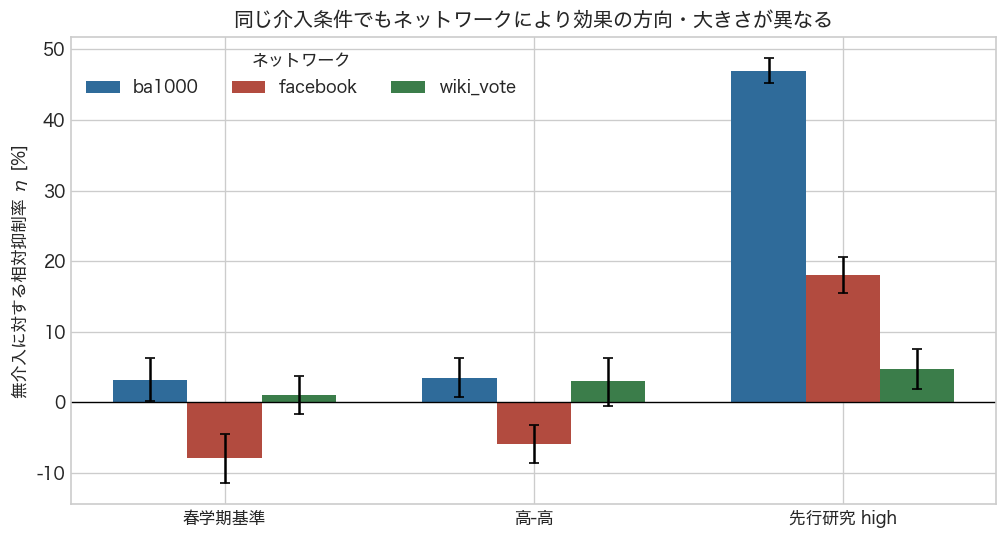

,network,candidate,relative_suppression,relative_ci_low,relative_ci_high,interpretation
6,ba1000,legacy_balance,0.032151,0.002109,0.062370,reduction
7,facebook,legacy_balance,-0.079234,-0.114451,-0.045557,increase
8,wiki_vote,legacy_balance,0.010641,-0.016983,0.037471,reduction_tendency_with_uncertainty
0,ba1000,grid_c100_e100,0.034470,0.006751,0.062124,reduction
1,facebook,grid_c100_e100,-0.059028,-0.085970,-0.032425,increase
2,wiki_vote,grid_c100_e100,0.030270,-0.005460,0.062907,reduction_tendency_with_uncertainty
3,ba1000,prior_high,0.470087,0.452738,0.487274,reduction
4,facebook,prior_high,0.180504,0.154671,0.205704,reduction
5,wiki_vote,prior_high,0.047215,0.019318,0.075625,reduction


In [3]:
condition_order = ['legacy_balance', 'grid_c100_e100', 'prior_high']
network_order = ['ba1000', 'facebook', 'wiki_vote']
formal = formal_effects[formal_effects['candidate'].isin(condition_order)].copy()
formal['condition'] = pd.Categorical(formal['candidate'], condition_order, ordered=True)
formal['network'] = pd.Categorical(formal['network'], network_order, ordered=True)
formal = formal.sort_values(['condition', 'network'])

fig, ax = plt.subplots(figsize=(8.5, 4.6))
x = np.arange(len(condition_order))
width = 0.24
colors = {'ba1000': '#2f6b9a', 'facebook': '#b24b3f', 'wiki_vote': '#3b7d4a'}
for offset, network in enumerate(network_order):
    part = formal[formal['network'] == network].set_index('candidate').reindex(condition_order)
    y = part['relative_suppression'].to_numpy() * 100
    low = (part['relative_suppression'] - part['relative_ci_low']).to_numpy() * 100
    high = (part['relative_ci_high'] - part['relative_suppression']).to_numpy() * 100
    ax.bar(x + (offset - 1) * width, y, width, label=network, color=colors[network], yerr=[low, high], capsize=3)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x, ['春学期基準', '高-高', '先行研究 high'])
ax.set_ylabel('無介入に対する相対抑制率 η [%]')
ax.set_title('同じ介入条件でもネットワークにより効果の方向・大きさが異なる')
ax.legend(title='ネットワーク', ncol=3)
fig.tight_layout()
fig.savefig(FIGURE_ROOT / 'formal_network_intervention_effects.png', bbox_inches='tight')
plt.show()
display(formal[['network', 'candidate', 'relative_suppression', 'relative_ci_low', 'relative_ci_high', 'interpretation']])

春学期基準はBA1000で明確な抑制、Facebookで明確な増加、Wiki-voteでは不確実である。一方、正しい `prior_high` は3ネットワークすべてで明確な抑制を示すが、相対抑制率はBA1000、Facebook、Wiki-voteの順に小さくなる。したがって、ネットワーク差は効果量と方向の両方で無視できない。

## 3. LFRコミュニティ構造

findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


...

findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


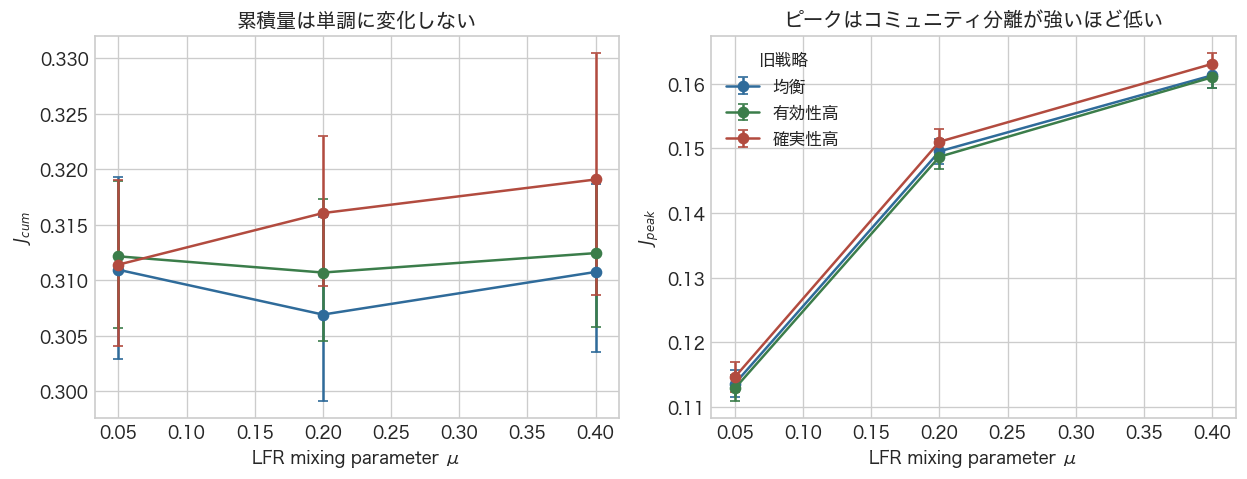

,structure_level,n_blocks,mean_jcum_strategy_range,jcum_block_interval_low,jcum_block_interval_high
5,middle,3,0.009833,0.00604,0.01203
6,strong,3,0.005473,0.00357,0.00842
7,weak,3,0.012743,0.00662,0.02100


In [4]:
lfr = levels[levels['dataset'] == 'lfr_community'].copy()
mu_map = {'strong': 0.05, 'middle': 0.20, 'weak': 0.40}
lfr['mu'] = lfr['structure_level'].map(mu_map)
strategy_labels = {'balance': '均衡', 'effective_high': '有効性高', 'certainty_high': '確実性高'}
strategy_colors = {'balance': '#2f6b9a', 'effective_high': '#3b7d4a', 'certainty_high': '#b24b3f'}

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.1))
for strategy in ['balance', 'effective_high', 'certainty_high']:
    part = lfr[lfr['strategy'] == strategy].sort_values('mu')
    for ax, metric, label in [(axes[0], 'jcum', '$J_{cum}$'), (axes[1], 'jpeak', '$J_{peak}$')]:
        y = part[f'{metric}_estimate'].to_numpy()
        low = y - part[f'{metric}_ci_low'].to_numpy()
        high = part[f'{metric}_ci_high'].to_numpy() - y
        ax.errorbar(part['mu'], y, yerr=[low, high], marker='o', capsize=3, label=strategy_labels[strategy], color=strategy_colors[strategy])
        ax.set_xlabel('LFR mixing parameter μ')
        ax.set_ylabel(label)
axes[0].set_title('累積量は単調に変化しない')
axes[1].set_title('ピークはコミュニティ分離が強いほど低い')
axes[1].legend(title='旧戦略')
fig.tight_layout()
fig.savefig(FIGURE_ROOT / 'legacy_lfr_jcum_jpeak.png', bbox_inches='tight')
plt.show()
display(sensitivity[sensitivity['dataset'] == 'lfr_community'][['structure_level', 'n_blocks', 'mean_jcum_strategy_range', 'jcum_block_interval_low', 'jcum_block_interval_high']])

強いコミュニティ分離では $J_{\mathrm{peak}}$ が低いが、$J_{\mathrm{cum}}$ はmixing parameterに対して単調ではない。旧戦略間の $J_{\mathrm{cum}}$ 範囲も強分離で小さい記述傾向はあるものの、ネットワークseedは各水準3個であり、無介入との差でもない。確認実験までは「コミュニティ分離が介入効果を弱める」とは断定しない。

## 4. Facebookの次数保存組み替え

findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


...

findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


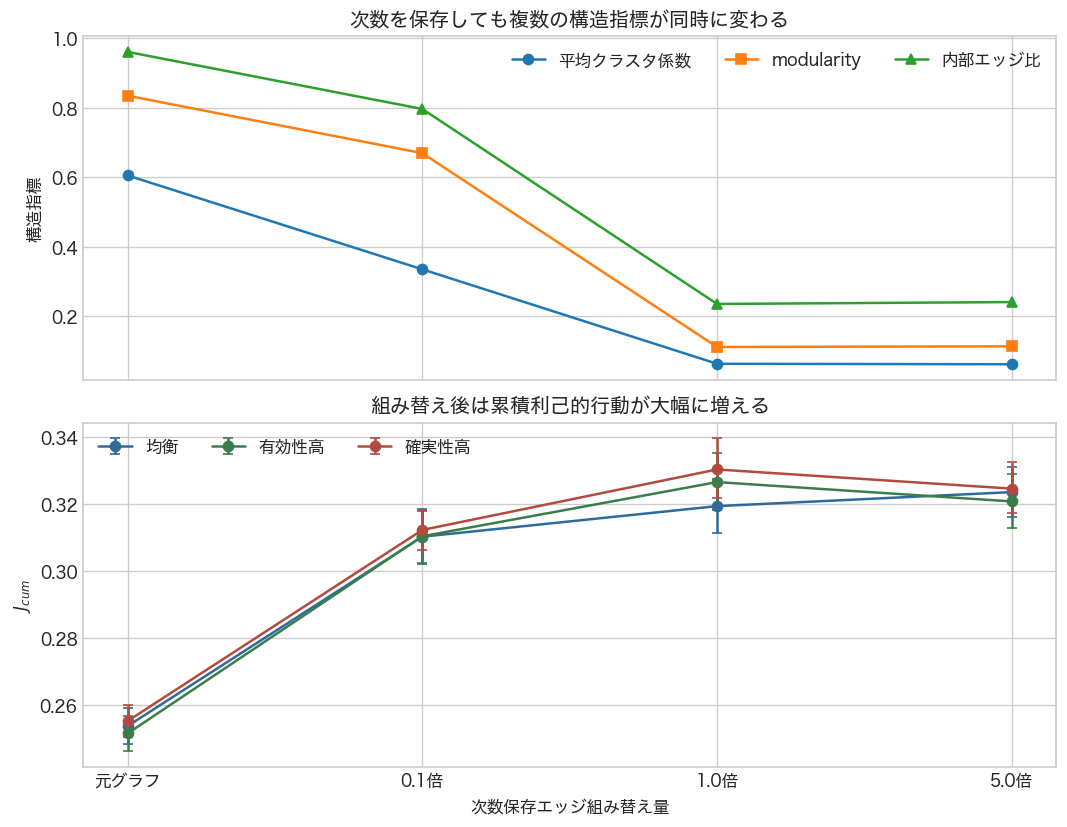

In [5]:
rewire = levels[levels['dataset'] == 'facebook_degree_rewire'].copy()
rewire_order = ['original', 'rewire_0p1', 'rewire_1p0', 'rewire_5p0']
rewire['order'] = rewire['structure_level'].map({name: i for i, name in enumerate(rewire_order)})
metrics = inventory[inventory['dataset'] == 'facebook_degree_rewire'].groupby('structure_level', as_index=False).agg(
    swap_ratio=('swap_ratio', 'first'),
    avg_clustering=('avg_clustering', 'first'),
    modularity=('louvain_modularity', 'first'),
    internal_edge_ratio=('louvain_internal_edge_ratio', 'first'),
)
metrics['order'] = metrics['structure_level'].map({name: i for i, name in enumerate(rewire_order)})
metrics = metrics.sort_values('order')

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].plot(metrics['order'], metrics['avg_clustering'], marker='o', label='平均クラスタ係数')
axes[0].plot(metrics['order'], metrics['modularity'], marker='s', label='modularity')
axes[0].plot(metrics['order'], metrics['internal_edge_ratio'], marker='^', label='内部エッジ比')
axes[0].set_ylabel('構造指標')
axes[0].set_title('次数を保存しても複数の構造指標が同時に変わる')
axes[0].legend(ncol=3)
for strategy in ['balance', 'effective_high', 'certainty_high']:
    part = rewire[rewire['strategy'] == strategy].sort_values('order')
    axes[1].errorbar(part['order'], part['jcum_estimate'], yerr=[part['jcum_estimate'] - part['jcum_ci_low'], part['jcum_ci_high'] - part['jcum_estimate']], marker='o', capsize=3, label=strategy_labels[strategy], color=strategy_colors[strategy])
axes[1].set_ylabel('$J_{cum}$')
axes[1].set_xticks(range(4), ['元グラフ', '0.1倍', '1.0倍', '5.0倍'])
axes[1].set_xlabel('次数保存エッジ組み替え量')
axes[1].set_title('組み替え後は累積利己的行動が大幅に増える')
axes[1].legend(ncol=3)
fig.tight_layout()
fig.savefig(FIGURE_ROOT / 'legacy_facebook_rewiring.png', bbox_inches='tight')
plt.show()

元グラフから組み替えると、3戦略すべてで $J_{\mathrm{cum}}$ と $J_{\mathrm{peak}}$ が明確に増える。ただし、クラスタ係数、modularity、内部エッジ比、初期発信者の外部接続性などが同時に変わっているため、どれか1指標の因果効果とは表現しない。また、旧データだけでは無介入水準も同時に上昇したのか、介入効果自体が変わったのかを分離できない。

## 5. 初期発信者候補とpower-law構造の補助結果

,dataset,metric,comparisons,clear_differences
0,lfr_facebook_pool,cumulative_selfish_fraction,9,0
1,lfr_facebook_pool,peak_new_selfish_ratio,9,6
2,lfr_rust_target_pool,cumulative_selfish_fraction,6,1
3,lfr_rust_target_pool,peak_new_selfish_ratio,6,3


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


...

findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


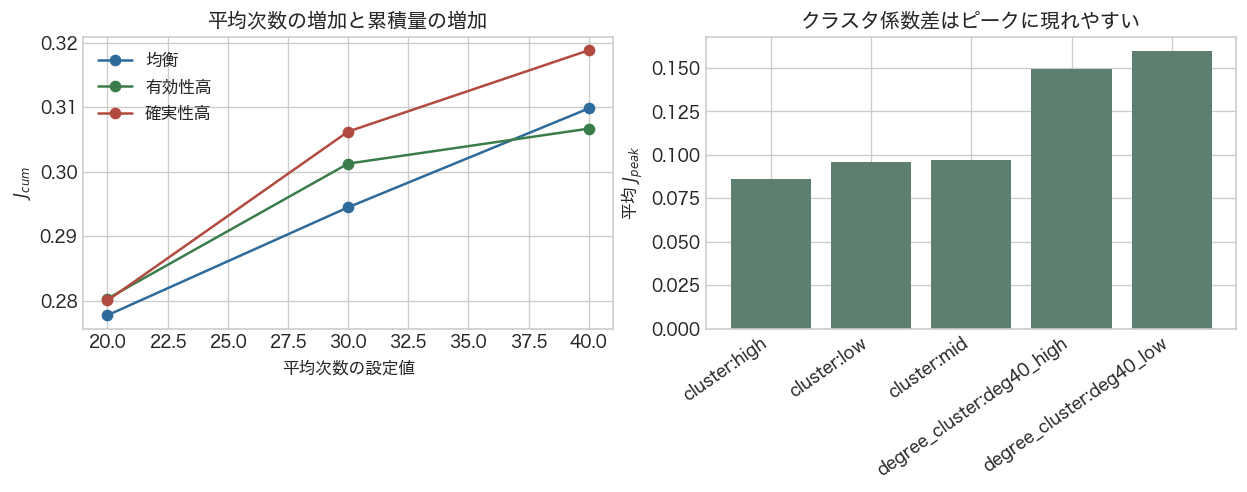

In [6]:
pool = paired[(paired['dataset'].isin(['lfr_facebook_pool', 'lfr_rust_target_pool'])) & (paired['metric'].isin(['cumulative_selfish_fraction', 'peak_new_selfish_ratio']))].copy()
pool['clear'] = (pool['difference_ci_low'] > 0) | (pool['difference_ci_high'] < 0)
display(pool.groupby(['dataset', 'metric']).agg(comparisons=('candidate_structure', 'size'), clear_differences=('clear', 'sum')).reset_index())

degree = levels[levels['dataset'] == 'powerlaw_degree'].copy()
degree['degree'] = degree['structure_level'].str.extract(r'(\d+)').astype(int)
cluster = levels[levels['dataset'].isin(['powerlaw_cluster', 'powerlaw_degree_cluster'])].copy()
cluster['group'] = cluster['dataset'] + ':' + cluster['structure_level']

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
for strategy in ['balance', 'effective_high', 'certainty_high']:
    part = degree[degree['strategy'] == strategy].sort_values('degree')
    axes[0].plot(part['degree'], part['jcum_estimate'], marker='o', label=strategy_labels[strategy], color=strategy_colors[strategy])
axes[0].set_xlabel('平均次数の設定値')
axes[0].set_ylabel('$J_{cum}$')
axes[0].set_title('平均次数の増加と累積量の増加')
axes[0].legend()
peak_means = cluster.groupby(['dataset', 'structure_level'], as_index=False)['jpeak_estimate'].mean()
labels = [f"{d.replace('powerlaw_', '')}:{s}" for d, s in zip(peak_means['dataset'], peak_means['structure_level'])]
axes[1].bar(np.arange(len(peak_means)), peak_means['jpeak_estimate'], color='#5d7f6f')
axes[1].set_xticks(np.arange(len(peak_means)), labels, rotation=35, ha='right')
axes[1].set_ylabel('平均 $J_{peak}$')
axes[1].set_title('クラスタ係数差はピークに現れやすい')
fig.tight_layout()
fig.savefig(FIGURE_ROOT / 'legacy_powerlaw_structure.png', bbox_inches='tight')
plt.show()

初期発信者候補の変更は累積量よりピークに一貫して現れた。power-law graphでは平均次数の増加に伴う基準的な結果水準の上昇が比較的明確で、クラスタ係数差は累積量よりピークに現れやすい。ただし、これらも無介入との相対効果ではない。

## 6. 旧戦略間差の安定性

In [7]:
strategy_contrasts['clear'] = (strategy_contrasts['difference_ci_low'] > 0) | (strategy_contrasts['difference_ci_high'] < 0)
contrast_counts = strategy_contrasts.groupby('metric').agg(total=('clear', 'size'), clear=('clear', 'sum')).reset_index()
display(contrast_counts)
display(strategy_contrasts[strategy_contrasts['clear']][['dataset', 'structure_level', 'comparison_id', 'metric', 'reference_minus_candidate', 'difference_ci_low', 'difference_ci_high']])

,metric,total,clear
0,cumulative_selfish_fraction,114,8
1,peak_new_selfish_ratio,114,85


,dataset,structure_level,comparison_id,metric,reference_minus_candidate,difference_ci_low,difference_ci_high
4,ba_topology,ba1000_topology,certainty_high_vs_balance,peak_new_selfish_ratio,-0.001868,-0.002788,-0.000910
5,ba_topology,ba1000_topology,effective_high_vs_certainty_high,peak_new_selfish_ratio,0.002122,0.000952,0.003360
11,facebook_degree_rewire,original,effective_high_vs_certainty_high,peak_new_selfish_ratio,0.000308,0.000072,0.000541
16,facebook_degree_rewire,rewire_0p1,certainty_high_vs_balance,peak_new_selfish_ratio,-0.000580,-0.000963,-0.000187
17,facebook_degree_rewire,rewire_0p1,effective_high_vs_certainty_high,peak_new_selfish_ratio,0.000831,0.000524,0.001109
...,...,...,...,...,...,...,...
215,powerlaw_node_count_graph_comm,n4000_deg40_low,effective_high_vs_certainty_high,peak_new_selfish_ratio,0.002414,0.001657,0.003032
219,real_network_legacy,facebook,effective_high_vs_balance,peak_new_selfish_ratio,0.000295,0.000010,0.000569
225,real_network_legacy,wiki-vote,effective_high_vs_balance,peak_new_selfish_ratio,0.000294,0.000062,0.000528
226,real_network_legacy,wiki-vote,certainty_high_vs_balance,peak_new_selfish_ratio,-0.000444,-0.000704,-0.000190


3つの旧戦略は確実性と有効性の両方が同時に異なるため、単独変数の効果ではない。さらに、明確な条件差は比較全体の一部に限られ、方向も構造ごとに異なる。したがって、普遍的な旧戦略順位は支持されない。

## 7. 第9段階の確認実験（結果が存在する場合）

In [8]:
confirmation_parent = REPO_ROOT / 'experiments/summer_2026/stage9_structure_confirmation'
analysis_candidates = sorted(confirmation_parent.glob('*/structure_confirmation_analysis_v01')) if confirmation_parent.exists() else []
if not analysis_candidates:
    print('確認実験は未実行です。既存357実行の再集計結果だけを表示しています。')
else:
    confirmation_root = analysis_candidates[-1]
    confirmation_effects = pd.read_csv(confirmation_root / 'tables/intervention_effects.csv')
    confirmation_contrasts = pd.read_csv(confirmation_root / 'tables/structure_effect_contrasts.csv')
    display(confirmation_effects[['family', 'structure_level', 'candidate', 'reference_estimate', 'intervention_estimate', 'relative_suppression', 'relative_ci_low', 'relative_ci_high', 'interpretation']])
    display(confirmation_contrasts[['family', 'reference_structure', 'candidate_structure', 'condition_id', 'relative_suppression_difference_candidate_minus_reference', 'relative_suppression_difference_ci_low', 'relative_suppression_difference_ci_high', 'interpretation']])

確認実験は未実行です。既存357実行の再集計結果だけを表示しています。


## 現時点の結論

1. ネットワークによって同じ介入の効果量と方向が異なることは、第4段階の無介入比較から支持される。
2. 既存構造実験では、次数保存組み替えが結果水準を大きく変え、LFRのコミュニティ分離や初期発信者候補がピークに影響することが示された。
3. 旧構造実験には無介入条件がないため、それらが介入効果 $\eta$ の差であるとはまだ言えない。
4. 複数の構造指標が同時に変化しており、modularityなど単一指標の因果効果は特定できない。
5. 対象をLFRコミュニティ分離とFacebook次数保存組み替えに限定し、無介入・春学期基準・`prior_high`を同じseedで比較する確認実験を実施する。